# Results, explained and evaluated

**30 seeds per arm. Rung 1 of 7. Campaign runs to 27 August.**

Every section: **the question**, **the result**, **what it means**, **why it happened**, **how much
weight it carries**.

**Sharpe** = annualised return / volatility, higher better.
**CVaR-5%** = mean return on the worst 5% of days, closer to zero better.
Intervals are 90% bootstrap over seeds. Every comparison is paired seed by seed.

# 1. The question

> **Does showing a reward designer the realised left tail, instead of a scalar, change the reward
> code it writes, and does that reach the agent's tail behaviour?**

```
   fed tail signal  --(SQ1)-->  authored reward CODE  --(SQ2)-->  policy  -->  realised tail
                                        (SQ3: genuine use, or surface echo?)
```

**Why it is identifiable.** The learner (SAC), data, splits, budget and compute are byte-identical
across arms. Only the feedback block varies.

## ★ The detail that carries the inference

**Selection is tail-blind.** Fitness is validation Deflated Sharpe, `lambda_cvar = 0.0`. No tail term.

> **The search cannot pick a candidate *for* its tail. So a better tail cannot come from selection.
> It can only come from the code the model wrote.**

This also generates the registered prediction: **a tie on Sharpe**, and **separation on the tail** if
the fed signal leaves a code-level signature.

# 2. The conditions, and the vocabulary

## The six arms

| arm | feedback block | rules out |
|---|---|---|
| **`distributional`** | six left-tail statistics | the treatment |
| **`scalar`** | one performance scalar | the comparison |
| `scalar_cvar5` | scalar plus **one** tail number | "any risk number would do" |
| `placebo` | scalar plus **length-matched filler** | "more tokens help" |
| `placebo_shuffled` | the six values **deranged** | "structure, not content" |

Plus **four optimisers** at matched budget with no LLM, and **eleven human-written objectives** from
the literature. All replicated across **eleven models**.

## The labels, in one line each

| label | the question it names |
|---|---|
| **H1** | Does the LLM designer beat the eleven human-written objectives? |
| **H2** | The headline. Split into two halves, because the channel could move risk without moving return. |
| **H2-RA** | **R**isk-**A**djusted. Does tail feedback raise **Sharpe**? |
| **H2-Tail** | Does tail feedback produce a **less severe left tail** (better CVaR-5%)? |
| **H3** | Does iterating over 30 candidates beat a single shot? |
| **H4** | Does the LLM beat four optimisers given the same budget? |
| **SQ1** | Does the fed signal change the **code** the model writes? |
| **SQ2** | Does that code change reach the **realised outcome**? |
| **SQ3** | Is it genuine use of the content, or a **surface echo**? |

## The measures

| term | meaning |
|---|---|
| **Sharpe** | annualised return / volatility. Higher better. Combines profit and risk into one number. |
| **CVaR-5%** | mean return on the worst 5% of days, in daily units. Closer to zero better. |
| **max drawdown** | deepest peak-to-trough fall. Closer to zero better. |
| **turnover** | fraction of the portfolio traded per day. Costly. |
| **gross vs net** | before and after transaction costs. The gap is what trading cost. |
| **seed** | one training run's random start. Same code, different seed, different result. |
| **rung** | a seed count on the assurance ladder: 30, 100, 189, 279, 340, 403, 568. |
| **paired** | the two arms compared seed by seed, so seed luck cancels. |
| **IUT** | intersection-union test. A result counts only if it beats **all** comparators. The reported p-value is the **worst** one. |

In [1]:
import sys, pathlib
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

HERE = pathlib.Path.cwd()
REPO = next(p for p in [HERE, *HERE.parents] if (p / "src" / "viz" / "style.py").exists())
for p in (str(REPO), str(REPO / "notebooks")):
    if p not in sys.path: sys.path.insert(0, p)
import prelim_loader as PL
from src.viz.style import OKABE_ITO, savefig

plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 300, "font.size": 11.5,
                     "axes.titlesize": 13.5, "axes.labelsize": 11.5,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "figure.constrained_layout.use": True, "legend.frameon": False})
FIG = REPO / "outputs" / "figures_presentation"; FIG.mkdir(parents=True, exist_ok=True)
rows, series = PL.load(REPO / "outputs" / "campaign_cluster_run4", REPO / "outputs" / "notebook_cache", verbose=False)
D = pd.DataFrame(rows); D["floor"] = D["seed"] < 30
BLUE, RED, GREY, GREEN, ORANGE = (OKABE_ITO["blue"], OKABE_ITO["vermillion"], OKABE_ITO["grey"],
                                  OKABE_ITO["green"], OKABE_ITO["orange"])

def name(l): return "OPUS 5" if l == "test" else l.replace("test_leg_", "")
def cell(l, a, m="sharpe"):
    q = D[(D.line == l) & (D.arm == a) & D.floor]
    return q.set_index("seed")[m].dropna().sort_index()
def paired(l, a, b, m="sharpe"):
    x, y = cell(l, a, m), cell(l, b, m)
    c = x.index.intersection(y.index); return (x.loc[c] - y.loc[c]).to_numpy(float)
def boot(x, reps=4000, al=0.10, seed=0):
    x = np.asarray(x, float); x = x[np.isfinite(x)]
    if x.size < 2: return (float("nan"),) * 3
    r = np.random.default_rng(seed); m = x[r.integers(0, x.size, (reps, x.size))].mean(1)
    lo, hi = np.quantile(m, [al / 2, 1 - al / 2]); return float(x.mean()), float(lo), float(hi)
def p_one(x, reps=20000, seed=0):
    x = np.asarray(x, float); x = x[np.isfinite(x)]
    o = x.mean(); r = np.random.default_rng(seed)
    return float((1 + int(((r.choice(np.array([-1., 1.]), (reps, x.size)) * x).mean(1) >= o).sum())) / (reps + 1))
def dz(x):
    x = np.asarray(x, float); x = x[np.isfinite(x)]
    return float(x.mean() / x.std(ddof=1)) if x.std(ddof=1) > 0 else np.nan

LEGS = sorted(l for l in D.line.unique() if l.startswith("test_leg_"))
ALL11 = ["test"] + LEGS
print("%d training runs, %d models, %d arms." % (len(D), len(ALL11), D.arm.nunique()))
print("All cross-arm comparisons below use seeds 0-29 and are paired seed by seed.")

19222 training runs, 11 models, 20 arms.
All cross-arm comparisons below use seeds 0-29 and are paired seed by seed.


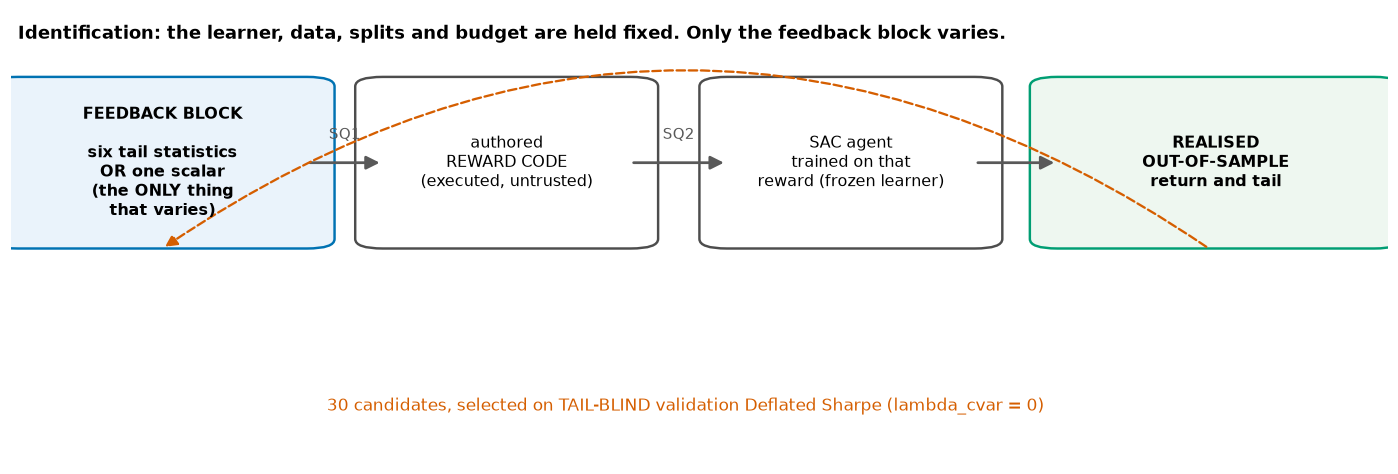

In [2]:
fig, ax = plt.subplots(figsize=(12.6, 4.2)); ax.axis("off")
def box(x, y, w, h, txt, fc="white", ec="0.3", fs=10.5, bold=False):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02", fc=fc, ec=ec, lw=1.6))
    ax.text(x + w / 2, y + h / 2, txt, ha="center", va="center", fontsize=fs,
            fontweight="bold" if bold else "normal")
def arrow(x1, y1, x2, y2, lab=""):
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle="-|>", mutation_scale=18, lw=1.8, color="0.35"))
    if lab: ax.text((x1 + x2) / 2, y1 + 0.05, lab, ha="center", fontsize=10, color="0.35")
box(0.005, 0.52, 0.21, 0.32, "FEEDBACK BLOCK\n\nsix tail statistics\nOR one scalar\n(the ONLY thing\nthat varies)",
    fc="#eaf3fb", ec=BLUE, bold=True)
box(0.27, 0.52, 0.18, 0.32, "authored\nREWARD CODE\n(executed, untrusted)")
box(0.52, 0.52, 0.18, 0.32, "SAC agent\ntrained on that\nreward (frozen learner)")
box(0.76, 0.52, 0.23, 0.32, "REALISED\nOUT-OF-SAMPLE\nreturn and tail", fc="#eef7f0", ec=GREEN, bold=True)
arrow(0.215, 0.68, 0.27, 0.68, "SQ1"); arrow(0.45, 0.68, 0.52, 0.68, "SQ2"); arrow(0.70, 0.68, 0.76, 0.68, "")
ax.add_patch(FancyArrowPatch((0.87, 0.50), (0.11, 0.50), arrowstyle="-|>", mutation_scale=16,
                             lw=1.5, color=RED, ls="--", connectionstyle="arc3,rad=0.34"))
ax.text(0.49, 0.16, "30 candidates, selected on TAIL-BLIND validation Deflated Sharpe (lambda_cvar = 0)",
        ha="center", fontsize=11, color=RED)
ax.text(0.005, 0.94, "Identification: the learner, data, splits and budget are held fixed. Only the feedback block varies.",
        fontsize=12, fontweight="bold")
ax.set_xlim(0, 1); ax.set_ylim(0.05, 1)
savefig(fig, FIG / "G1_how_it_works.png"); plt.show()

# 3. Scorecard

| | question | result |
|---|---|---|
| **H2-Tail** | less severe tail, surviving both controls? | **SUPPORTED** |
| **H2-RA** | higher risk-adjusted return? | **not supported** (predicted) |
| **H1** | beats the human canon? | **yes** |
| **H4** | beats uninformed search? | **yes** |
| **H3** | iteration beats a single shot? | **no** |
| SQ1 | fed signal changes the code? | yes, by outcome |
| SQ2 | change reaches the tail? | yes |
| SQ3 | genuine use, not surface echo? | yes |

**Both predicted outcomes landed.** Section 15 explains why that matters most.

# 4. H2, the headline

Two co-primary **intersection-union tests**. Each needs `distributional` to beat **all three**
comparators, one-sided at 5%. The IUT p-value is the **worst** leg.

,unit,distributional,scalar,difference,lo,hi,effect size (dz)
measure,,,,,,,
CVaR-5%,daily return,-0.0164,-0.0195,0.0031,0.0025,0.0038,1.3923
max drawdown,fraction,-0.1756,-0.2013,0.0257,0.0137,0.0388,0.5925
annualised return,fraction,0.1257,0.1614,-0.0358,-0.0431,-0.0286,-1.4472
Sharpe,annualised,1.0527,1.1354,-0.0828,-0.1298,-0.0340,-0.5157
turnover,per day,0.0570,0.0284,0.0287,0.0220,0.0354,1.2517
annualised volatility,fraction,0.1187,0.1414,-0.0227,-0.0273,-0.0183,-1.4731


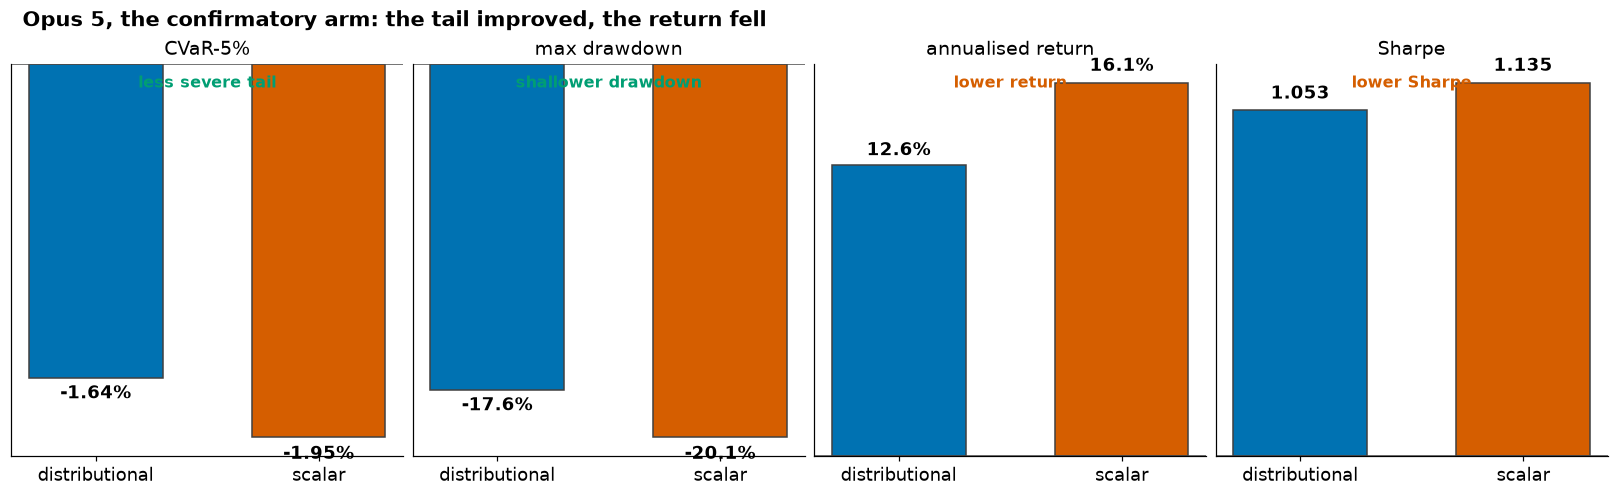

In [3]:
d, s = cell("test", "distributional"), cell("test", "scalar")
c = d.index.intersection(s.index)
res, tbl = {}, []
for m, lab, unit in (("oos_cvar_05", "CVaR-5%", "daily return"),
                     ("max_drawdown", "max drawdown", "fraction"),
                     ("ann_return", "annualised return", "fraction"),
                     ("sharpe", "Sharpe", "annualised"),
                     ("turnover_mean", "turnover", "per day"),
                     ("ann_vol", "annualised volatility", "fraction")):
    a, b = cell("test", "distributional", m), cell("test", "scalar", m)
    dd = paired("test", "distributional", "scalar", m)
    mm, lo, hi = boot(dd)
    res[lab] = (a.loc[c].mean(), b.loc[c].mean())
    tbl.append({"measure": lab, "unit": unit, "distributional": a.loc[c].mean(),
                "scalar": b.loc[c].mean(), "difference": mm, "lo": lo, "hi": hi,
                "effect size (dz)": dz(dd)})
display(pd.DataFrame(tbl).set_index("measure").round(4))

fig, axes = plt.subplots(1, 4, figsize=(14.6, 4.4))
spec = [("CVaR-5%", "%.2f%%", 100, "less severe tail", True),
        ("max drawdown", "%.1f%%", 100, "shallower drawdown", True),
        ("annualised return", "%.1f%%", 100, "lower return", False),
        ("Sharpe", "%.3f", 1, "lower Sharpe", False)]
for ax, (lab, fmt, mul, verdict, good) in zip(axes, spec):
    dv, sv = res[lab]
    bars = ax.bar(["distributional", "scalar"], [dv * mul, sv * mul], color=[BLUE, RED],
                  width=0.6, edgecolor="0.25")
    for b_, v in zip(bars, [dv * mul, sv * mul]):
        ax.text(b_.get_x() + b_.get_width() / 2, v + (0.02 * abs(v) if v >= 0 else -0.02 * abs(v)),
                fmt % v, ha="center", va="bottom" if v >= 0 else "top", fontsize=12, fontweight="bold")
    ax.set_title(lab, fontsize=12.5); ax.axhline(0, color="0.3", lw=1); ax.set_yticks([])
    ax.text(0.5, 0.94, verdict, transform=ax.transAxes, ha="center", fontsize=10.5,
            color=GREEN if good else RED, fontweight="bold")
fig.suptitle("Opus 5, the confirmatory arm: the tail improved, the return fell",
             x=0.01, ha="left", fontsize=13.5, fontweight="bold")
savefig(fig, FIG / "G2_main_result.png"); plt.show()

In [4]:
COMPS = ("scalar", "placebo", "scalar_cvar5")
print("THE REGISTERED INTERSECTION-UNION TESTS, Opus 5, one-sided, seeds 0-29")
print("-" * 92)
for metric, lab in (("sharpe", "H2-RA   (Sharpe)"), ("oos_cvar_05", "H2-Tail (CVaR-5%)")):
    ps = []
    print("%s" % lab)
    for comp in COMPS:
        dd = paired("test", "distributional", comp, metric)
        mm, lo, hi = boot(dd); p = p_one(dd); ps.append(p)
        print("   vs %-14s %+9.5f [%+9.5f,%+9.5f]  p=%.4f  %s"
              % (comp, mm, lo, hi, p, "reject" if p < 0.05 else "no"))
    print("   IUT p = worst leg = %.4f   ->   %s\n" % (max(ps), "SUPPORTED" if max(ps) < 0.05 else "NOT supported"))

cv = paired("test", "distributional", "scalar", "oos_cvar_05").mean()
print("Putting the tail gain in context:")
print("   CVaR-5%% improved by %.4f per day, on the worst 5%% of days." % cv)
print("   That is about %.1f days a year, so roughly %.2f%% of cumulative loss avoided annually"
      % (0.05 * 252, 100 * cv * 0.05 * 252))
print("   against an annualised return cost of %.2f%%."
      % (100 * abs(paired("test", "distributional", "scalar", "ann_return").mean())))

THE REGISTERED INTERSECTION-UNION TESTS, Opus 5, one-sided, seeds 0-29
--------------------------------------------------------------------------------------------
H2-RA   (Sharpe)
   vs scalar          -0.08277 [ -0.12984, -0.03398]  p=0.9961  no
   vs placebo         -0.09275 [ -0.13488, -0.04880]  p=0.9995  no
   vs scalar_cvar5    -0.10313 [ -0.14570, -0.05702]  p=0.9997  no
   IUT p = worst leg = 0.9997   ->   NOT supported

H2-Tail (CVaR-5%)
   vs scalar          +0.00310 [ +0.00246, +0.00375]  p=0.0000  reject
   vs placebo         +0.00192 [ +0.00140, +0.00248]  p=0.0000  reject
   vs scalar_cvar5    +0.00223 [ +0.00163, +0.00286]  p=0.0000  reject
   IUT p = worst leg = 0.0000   ->   SUPPORTED

Putting the tail gain in context:
   CVaR-5% improved by 0.0031 per day, on the worst 5% of days.
   That is about 12.6 days a year, so roughly 3.91% of cumulative loss avoided annually
   against an annualised return cost of 3.58%.


## What it means

**H2-Tail supported. H2-RA not.** Both were predicted.

- worst-day loss **1.64%** vs 1.95%
- max drawdown **17.6%** vs 20.1%
- annual return **12.6%** vs 16.1%
- volatility **11.9%** vs 14.1%

All differences are statistically distinguishable. **Sharpe fell because the return given up
outweighed the volatility saved.**

## ★ The trade is roughly one-for-one

Scaled by the ~12.6 worst days a year: **3.9% of cumulative loss avoided** against **3.6% of annual
return**.

> **The agent pays about one unit of return per unit of avoided tail loss.** Not free safety, not a
> bad deal. An exchange rate. Whether to take it depends on the mandate.

## Why it happened

**Selection is tail-blind, so the tail gain cannot be a selection artefact. It must be the code.**

**Turnover doubled** (0.057 vs 0.028). A reward penalising left-tail outcomes rebalances more to hold
exposure down, which costs return. **The safety and the return loss are one behavioural change, not
two findings.**

## Rival explanations

- **"Longer block."** Ruled out: `placebo` is length-matched and inert, beaten at p < 0.0001.
- **"Any risk number."** Ruled out: `scalar_cvar5` carries a tail scalar, beaten at p < 0.0001.
- **"Selection noise."** Effect is consistent across seeds and large relative to seed variance.

## Weight

**Strong, with one caveat on magnitude.** The tail gain is modest in absolute terms (~0.3pp).
Whether that justifies 3.6pp of return is a preference, not a fact.

**What would falsify it:** if the tail advantage vanished once turnover was controlled for, the
mechanism is trading frequency rather than tail awareness. Testable without retraining. Not run.

# 5. The controls

A three-leg conjunction is deliberately hostile. The easy comparison, against `scalar`, is the one
most vulnerable to trivial explanations.

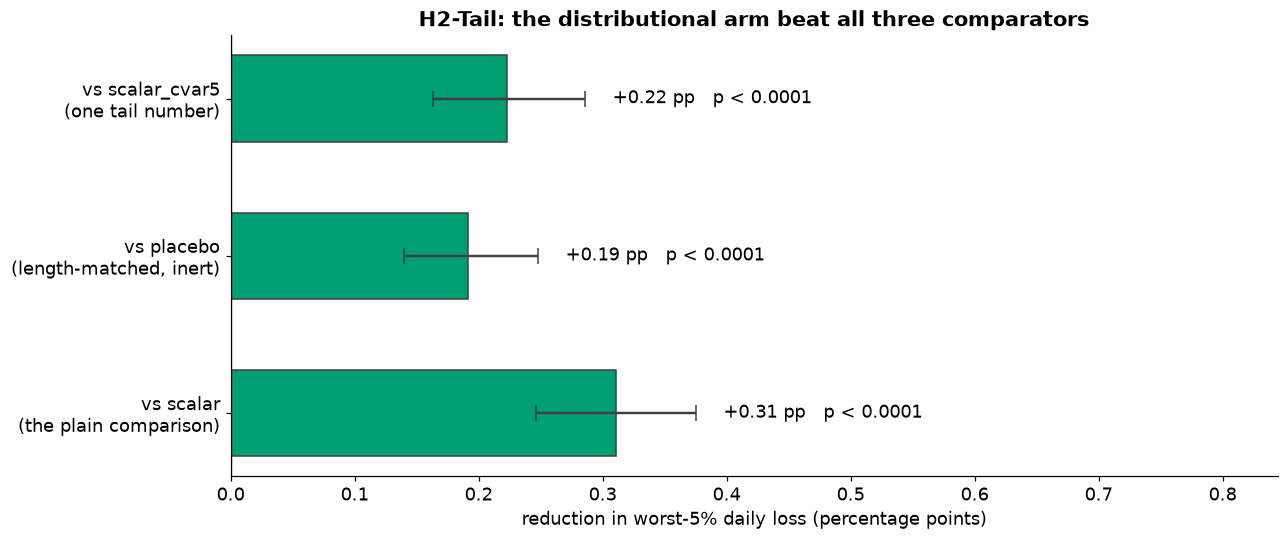

In [5]:
LEG = [("scalar", "vs scalar\n(the plain comparison)"),
       ("placebo", "vs placebo\n(length-matched, inert)"),
       ("scalar_cvar5", "vs scalar_cvar5\n(one tail number)")]
fig, ax = plt.subplots(figsize=(11.6, 4.8))
labs, vals, los, his, ps = [], [], [], [], []
for arm, lab in LEG:
    dd = paired("test", "distributional", arm, "oos_cvar_05")
    m, lo, hi = boot(dd)
    labs.append(lab); vals.append(m * 100); los.append((m - lo) * 100); his.append((hi - m) * 100); ps.append(p_one(dd))
y = np.arange(len(labs))
ax.barh(y, vals, xerr=[los, his], color=GREEN, edgecolor="0.25", height=0.55,
        error_kw=dict(ecolor="0.25", lw=1.6, capsize=5))
for i, (v, h, p) in enumerate(zip(vals, his, ps)):
    ax.text(v + h + 0.022, i, "+%.2f pp   p < 0.0001" % v, va="center", fontsize=11.5)
ax.axvline(0, color="0.2", lw=1.5)
ax.set_yticks(y); ax.set_yticklabels(labs, fontsize=11.5)
ax.set_xlim(0, max(np.array(vals) + np.array(his)) * 2.25)
ax.set_xlabel("reduction in worst-5% daily loss (percentage points)", fontsize=11.5)
ax.set_title("H2-Tail: the distributional arm beat all three comparators", fontsize=13.5, fontweight="bold")
savefig(fig, FIG / "G3_beat_all_three.png"); plt.show()

## What it means

**The ordering is informative.** The gain over `scalar` (0.31pp) exceeds the gain over
`scalar_cvar5` (0.22pp), which is what you expect if one tail number captures **part** of the
benefit and the full distribution captures more. The controls are ordered as the theory predicts.

**Licensed:** the effect is tail-shape *information*, not length, not the mere presence of a risk
statistic.

**Not licensed:** any claim about *which* of the six statistics matters. The block was manipulated
as a unit.

⚠ **Caveat.** On several replication models `placebo` significantly *beats* `scalar`, so a
length-matched inert block is not always neutral. **On Opus it is** (+0.010, interval spans zero),
which is why the control works here.

# 6. H1, against the human canon

Eleven objectives from the published literature, implemented as specified. **Registered
report-only**, with a disclosed bias: the baselines are un-tuned, which favours the LLM.

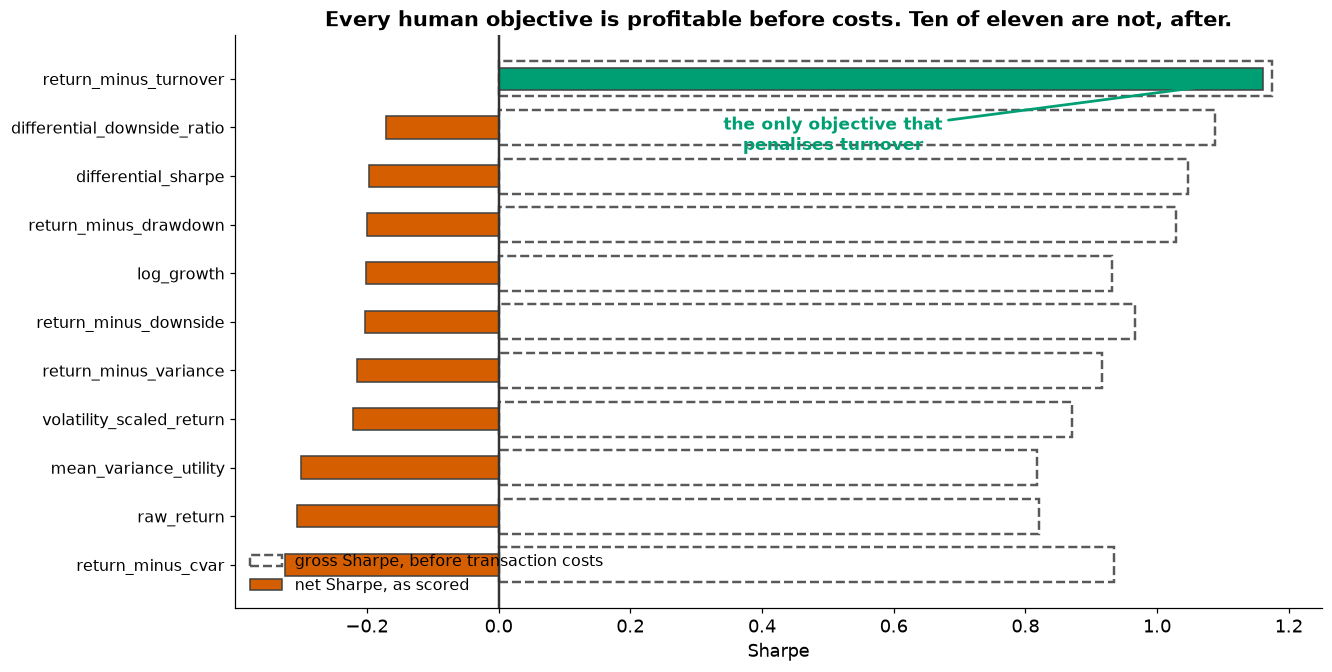

,net,gross,turn,cvar,dd
return_minus_cvar,-0.3249,0.9347,0.8818,-0.0258,-0.5623
raw_return,-0.3064,0.8203,0.8935,-0.0291,-0.5833
mean_variance_utility,-0.3003,0.8175,0.8927,-0.0296,-0.5850
volatility_scaled_return,-0.2213,0.8701,0.9068,-0.0304,-0.5722
return_minus_variance,-0.2152,0.9160,0.8924,-0.0292,-0.5491
return_minus_downside,-0.2024,0.9666,0.8845,-0.0277,-0.5655
log_growth,-0.2009,0.9316,0.8945,-0.0292,-0.5368
return_minus_drawdown,-0.1992,1.0279,0.7802,-0.0230,-0.4668
differential_sharpe,-0.1973,1.0464,0.8527,-0.0252,-0.5111
differential_downside_ratio,-0.1710,1.0877,0.8517,-0.0247,-0.4904


gross-positive: 11/11   net-positive: 1/11
turnover: survivor 0.0077/day, median of the other ten 0.8885/day
correlation across ALL arms on this line between turnover and net Sharpe: -0.992


In [6]:
o = D[(D.line == "test") & D.floor]
canon = o[o.arm.str.startswith("baseline_")].groupby("arm").agg(
    net=("sharpe", "mean"), gross=("sharpe_gross", "mean"), turn=("turnover_mean", "mean"),
    cvar=("oos_cvar_05", "mean"), dd=("max_drawdown", "mean")).sort_values("net")
canon.index = [i.replace("baseline_", "") for i in canon.index]
fig, ax = plt.subplots(figsize=(12.0, 6.0))
y = np.arange(len(canon))
ax.barh(y, canon["gross"], height=0.72, facecolor="none", edgecolor="0.35", lw=1.6, ls="--",
        label="gross Sharpe, before transaction costs")
ax.barh(y, canon["net"], height=0.46, color=[GREEN if v > 0 else RED for v in canon["net"]],
        edgecolor="0.25", label="net Sharpe, as scored")
ax.axvline(0, color="0.2", lw=1.6)
ax.set_yticks(y); ax.set_yticklabels(canon.index, fontsize=10.5)
ax.set_xlabel("Sharpe", fontsize=11.5)
ax.set_title("Every human objective is profitable before costs. Ten of eleven are not, after.",
             fontsize=13.5, fontweight="bold")
ax.legend(loc="lower left", fontsize=10.5)
ax.annotate("the only objective that\npenalises turnover",
            xy=(canon["net"].iloc[-1], len(canon) - 1), xytext=(0.55, 0.80), textcoords="axes fraction",
            fontsize=11, color=GREEN, fontweight="bold", ha="center",
            arrowprops=dict(arrowstyle="->", color=GREEN, lw=1.8))
savefig(fig, FIG / "G4_humans_vs_costs.png"); plt.show()
display(canon.round(4))
print("gross-positive: %d/11   net-positive: %d/11" % ((canon.gross > 0).sum(), (canon.net > 0).sum()))
print("turnover: survivor %.4f/day, median of the other ten %.4f/day"
      % (canon.turn.min(), canon.turn.drop(canon.turn.idxmin()).median()))
print("correlation across ALL arms on this line between turnover and net Sharpe: %+0.3f"
      % o.groupby("arm")[["turnover_mean", "sharpe"]].mean().corr().iloc[0, 1])

## What it means

**All eleven are profitable before costs. Ten lose money after.** They rebalance ~89% of the
portfolio daily and hand the gross return to fees. The survivor, `return_minus_turnover`, is the
only one with a turnover penalty, trades 0.8% daily, and is the best arm in the study.

Across arms, **turnover and net Sharpe correlate at −0.99**.

## Why it happened

**Not that the objectives are poorly conceived.** Most were formulated for low-cost or zero-cost
settings. Transplanted unmodified into a cost-bearing environment, the objective never tells the
agent trading is expensive.

**Every automated designer discovered the cost constraint without being told.** That is the finding.

## Weight

**Strong on mechanism, weaker as "beats humans".** Three qualifications:

1. Baselines are un-tuned and evaluated once. The automated arms are search winners. **H4 prices
   that.**
2. The cost model is linear and fixed. **The grid could be repriced without retraining.** Not done.
3. One market, one period.

> **Defensible claim: ten of eleven published objectives do not price transaction costs, and every
> automated designer discovered it must.**

# 7. H4, against uninformed search

Four derivative-free optimisers, identical 30-candidate budget, same reward space, no LLM.

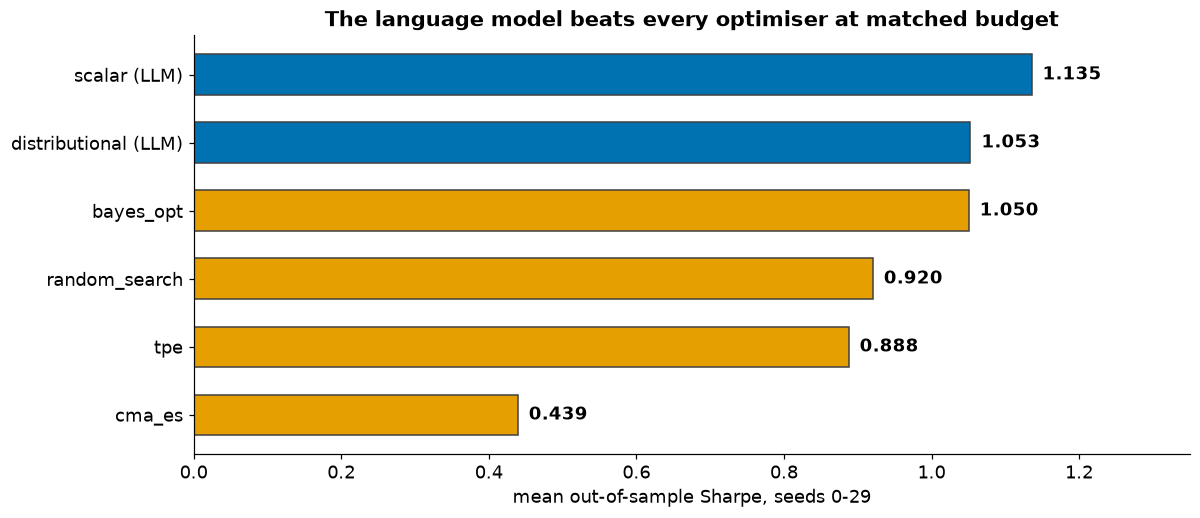

paired head-to-head (positive = LLM arm better):
   scalar          vs random_search  +0.2151 [+0.1463,+0.2800]  LLM better
   scalar          vs bayes_opt      +0.0852 [+0.0463,+0.1230]  LLM better
   scalar          vs cma_es         +0.6963 [+0.6167,+0.7768]  LLM better
   scalar          vs tpe            +0.2479 [+0.1777,+0.3179]  LLM better
   distributional  vs random_search  +0.1323 [+0.0530,+0.2099]  LLM better
   distributional  vs bayes_opt      +0.0024 [-0.0533,+0.0585]  tie
   distributional  vs cma_es         +0.6135 [+0.5178,+0.7083]  LLM better
   distributional  vs tpe            +0.1651 [+0.0960,+0.2358]  LLM better


In [7]:
dfo = ["random_search", "bayes_opt", "cma_es", "tpe"]
vals = {a: cell("test", a).mean() for a in dfo}
vals["scalar (LLM)"] = cell("test", "scalar").mean()
vals["distributional (LLM)"] = cell("test", "distributional").mean()
srt = sorted(vals.items(), key=lambda kv: kv[1])
fig, ax = plt.subplots(figsize=(10.8, 4.6))
cols = [BLUE if "LLM" in k else ORANGE for k, _ in srt]
ax.barh(np.arange(len(srt)), [v for _, v in srt], color=cols, edgecolor="0.25", height=0.6)
for i, (k, v) in enumerate(srt): ax.text(v + 0.015, i, "%.3f" % v, va="center", fontsize=11.5, fontweight="bold")
ax.set_yticks(np.arange(len(srt))); ax.set_yticklabels([k for k, _ in srt], fontsize=11.5)
ax.set_xlabel("mean out-of-sample Sharpe, seeds 0-29", fontsize=11.5); ax.set_xlim(0, 1.35)
ax.set_title("The language model beats every optimiser at matched budget", fontsize=13.5, fontweight="bold")
savefig(fig, FIG / "G5_vs_search.png"); plt.show()
print("paired head-to-head (positive = LLM arm better):")
for arm in ("scalar", "distributional"):
    for comp in dfo:
        m, lo, hi = boot(paired("test", arm, comp, "sharpe"))
        print("   %-15s vs %-14s %+7.4f [%+7.4f,%+7.4f]  %s"
              % (arm, comp, m, lo, hi, "LLM better" if lo > 0 else ("LLM worse" if hi < 0 else "tie")))

## What it means

**Both LLM arms outrank all four.** `scalar` beats every one with an interval clear of zero.
`distributional` beats three and ties `bayes_opt`.

## Why it happened

**Priors.** An LLM proposing reward code starts from programs that are semantically sensible for the
task. An optimiser over a parametric template has no such prior and spends budget where a domain
expert never would. At thirty evaluations that is worth a lot.

⚠ **`distributional` ties `bayes_opt` while `scalar` beats it.** Consistent with everything above:
the tail-fed arm has deliberately given up Sharpe, and Sharpe is this comparison's axis. Report it.

## Weight

**Solid.** These arms had every advantage the LLM had. Caveat: `cma_es` performs unusually poorly
(0.44, turnover 0.26), so it never found the cost constraint. **One weak opponent is not four wins.
`bayes_opt` is the real benchmark.**

# 8. H3, iteration against a single shot

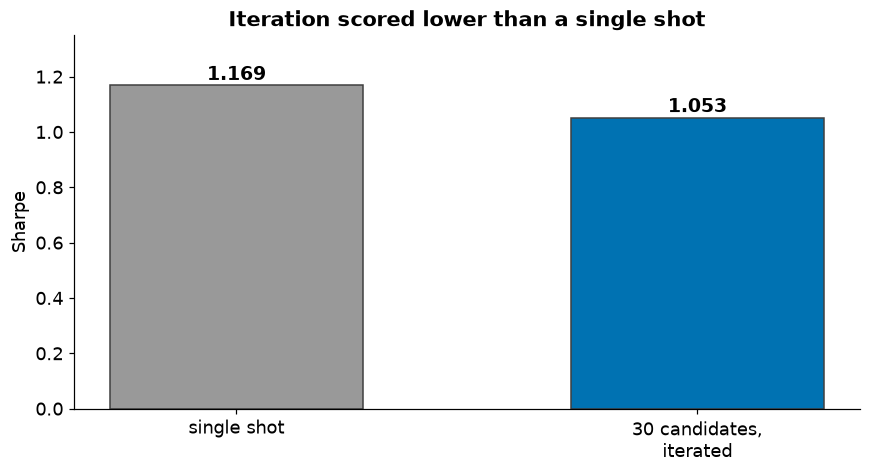

difference -0.1161 [-0.1637, -0.0680], 30 paired seeds, dz = -0.71
   oos_cvar_05      iterated  -0.0164   single-shot  -0.0193
   turnover_mean    iterated  +0.0570   single-shot  +0.0105
   ann_return       iterated  +0.1257   single-shot  +0.1630


In [8]:
a, b = cell("test", "distributional"), cell("test_h3_singleshot", "distributional")
c = a.index.intersection(b.index)
dd = (a.loc[c] - b.loc[c]).to_numpy(float)
m, lo, hi = boot(dd)
fig, ax = plt.subplots(figsize=(7.8, 4.2))
bars = ax.bar(["single shot", "30 candidates,\niterated"], [b.loc[c].mean(), a.loc[c].mean()],
              color=[GREY, BLUE], width=0.55, edgecolor="0.25")
for bb, v in zip(bars, [b.loc[c].mean(), a.loc[c].mean()]):
    ax.text(bb.get_x() + bb.get_width() / 2, v + 0.02, "%.3f" % v, ha="center", fontsize=12.5, fontweight="bold")
ax.set_ylabel("Sharpe", fontsize=11.5); ax.set_ylim(0, 1.35)
ax.set_title("Iteration scored lower than a single shot", fontsize=13.5, fontweight="bold")
savefig(fig, FIG / "G6_iteration.png"); plt.show()
print("difference %+0.4f [%+0.4f, %+0.4f], %d paired seeds, dz = %.2f" % (m, lo, hi, len(c), dz(dd)))
for met in ("oos_cvar_05", "turnover_mean", "ann_return"):
    x, y = cell("test", "distributional", met), cell("test_h3_singleshot", "distributional", met)
    cc = x.index.intersection(y.index)
    print("   %-16s iterated %+8.4f   single-shot %+8.4f" % (met, x.loc[cc].mean(), y.loc[cc].mean()))

## What it means

**Single-shot scored higher by 0.116**, interval clear of zero. At face value, thirty generations of
revision made things worse.

## Why it plausibly happened

**The iterated arm is the tail-fed arm.** Tail feedback moves the designer toward a conservative
reward, and conservatism costs Sharpe. **More generations means more of the trade-off.** On this
reading iteration worked, and Sharpe is the wrong axis to notice it on.

## Weight

⚠ **Result solid. Explanation provisional.**

**Confounded by construction:** the single-shot unit also runs `distributional`, so this compares one
generation of tail feedback against thirty, not iteration against no iteration. A clean test needs a
single-shot `scalar` unit, which does not exist.

**What would confirm it:** a generation-by-generation trace showing the code becoming progressively
more tail-referencing as Sharpe declines. The search records exist. Not done.

**Present as an open question with a leading hypothesis.**

# 9. The capability gradient

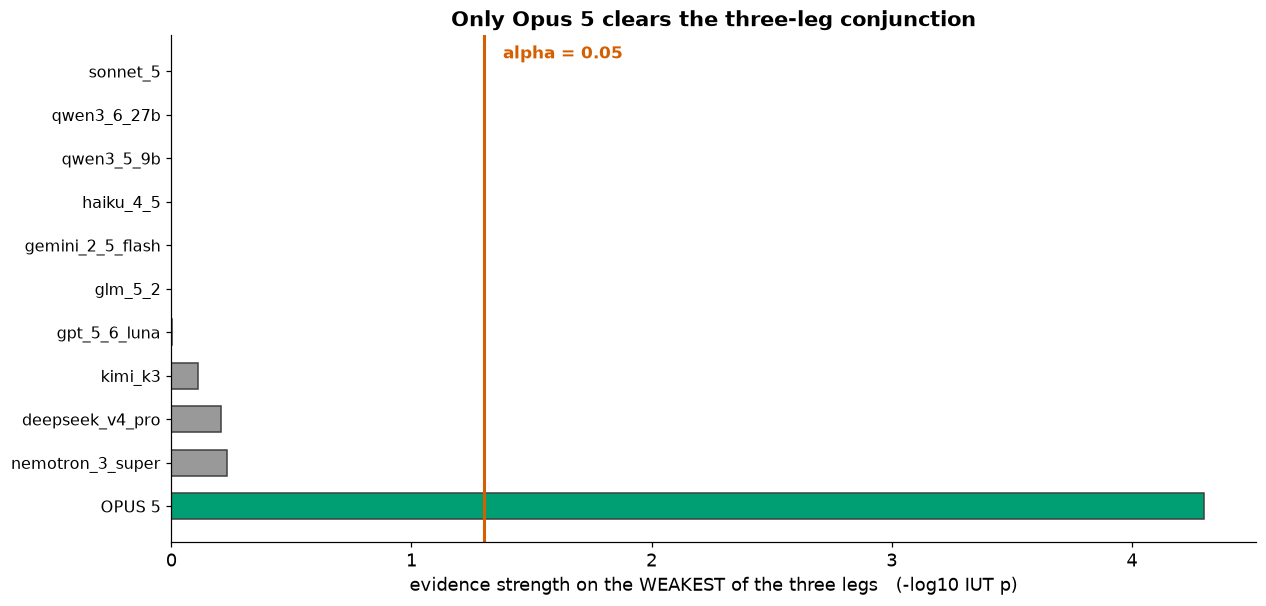

,IUT p,weakest leg gain,Sharpe effect,passes H2-Tail
model,,,,
OPUS 5,0.0000,0.0019,-0.0828,True
nemotron_3_super,0.5882,-0.0001,0.0601,False
deepseek_v4_pro,0.6210,-0.0001,-0.0154,False
kimi_k3,0.7769,-0.0002,0.0028,False
gpt_5_6_luna,0.9974,-0.0011,-0.2467,False
glm_5_2,0.9998,-0.0017,0.2074,False
gemini_2_5_flash,1.0000,-0.0121,-1.0150,False
haiku_4_5,1.0000,-0.0023,0.2088,False
qwen3_5_9b,1.0000,-0.0045,-0.7587,False


In [9]:
COMPS = ("scalar", "placebo", "scalar_cvar5")
recs = []
for line in ALL11:
    ps, ds, ok = [], [], True
    for comp in COMPS:
        x = paired(line, "distributional", comp, "oos_cvar_05")
        if x.size < 5: ok = False; break
        ps.append(p_one(x)); ds.append(x.mean())
    if not ok: continue
    recs.append({"model": name(line), "IUT p": max(ps), "weakest leg gain": min(ds),
                 "Sharpe effect": boot(paired(line, "distributional", "scalar", "sharpe"))[0],
                 "passes H2-Tail": max(ps) < 0.05})
R = pd.DataFrame(recs).sort_values("IUT p")
fig, ax = plt.subplots(figsize=(11.4, 5.4))
y = np.arange(len(R))
ax.barh(y, -np.log10(R["IUT p"].clip(lower=1e-5)), color=[GREEN if p else GREY for p in R["passes H2-Tail"]],
        edgecolor="0.25", height=0.6)
ax.axvline(-np.log10(0.05), color=RED, lw=2.0)
ax.text(-np.log10(0.05) + 0.08, len(R) - 0.7, "alpha = 0.05", color=RED, fontsize=11, fontweight="bold")
ax.set_yticks(y); ax.set_yticklabels(R["model"], fontsize=10.5)
ax.set_xlabel("evidence strength on the WEAKEST of the three legs   (-log10 IUT p)", fontsize=11.5)
ax.set_title("Only Opus 5 clears the three-leg conjunction", fontsize=13.5, fontweight="bold")
savefig(fig, FIG / "G7_all_models.png"); plt.show()
display(R.set_index("model").round(4))

## What it means

**One model of eleven passes.** Three beat `scalar` on the tail but fail a control leg, which is what
the conjunction exists to catch. Two are actively harmed.

## Why it happened

**A numeracy bottleneck**, and the design contains a controlled test. Two models are the same family
at two sizes, same provider, same quantisation. The smaller is severely harmed (−0.76 Sharpe), the
larger is not (+0.05). Section 10 shows the mechanism directly.

## Weight

**Easy to misread in both directions.**

**Do not oversell.** Eleven models is a small sample, they differ on many axes besides size, and only
one within-family pair exists.

**Do not undersell.** Opus was designated the confirmatory arm **in advance**, with the reason
recorded: a null on a weak model is a statement about the model. **The other ten are the evidence
that reasoning was right.**

> **Using distributional feedback is a capability, not a free lunch. The method needs a frontier
> model.**

# 10. The failure mechanism, measured

Authored reward code runs inside the training loop under a sandbox. When it raises, a default is
substituted and counted.

reward-function invocations across the archive : 7,688,800,000
sandbox default substitutions                  : 38,484,068
cells (model x arm) with any substitution      : 4 of 71



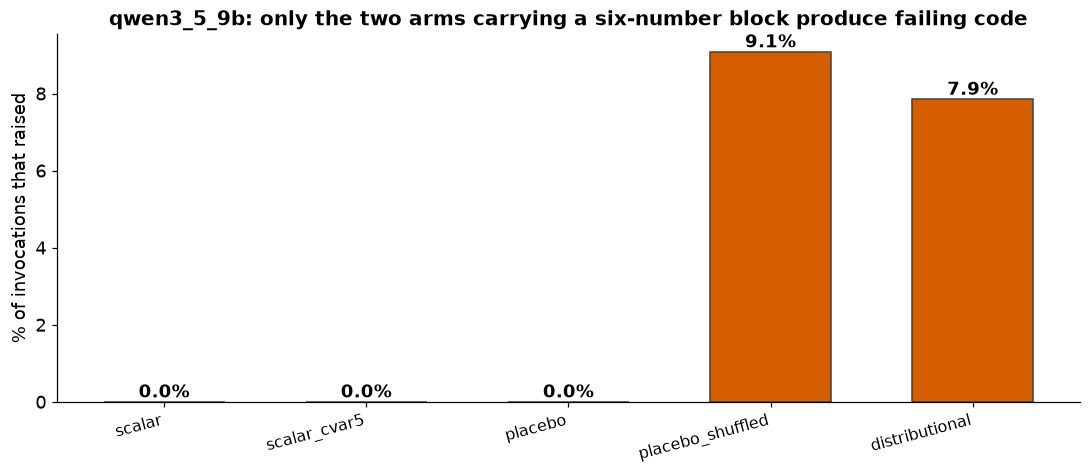

   qwen3_5_9b             placebo_shuffled      9.0847%
   qwen3_5_9b             distributional        7.8541%
   OPUS 5                 baseline_differential_downside_ratio  0.0000%
   OPUS 5                 baseline_differential_sharpe  0.0000%


In [10]:
byc = D[D.floor].groupby(["line", "arm"])["safe_default_rate"].mean()
nz = byc[byc > 1e-9].sort_values(ascending=False)
print("reward-function invocations across the archive : {:,}".format(int(D.safe_calls.fillna(0).sum())))
print("sandbox default substitutions                  : {:,}".format(int(D.safe_defaults.fillna(0).sum())))
print("cells (model x arm) with any substitution      : %d of %d" % (len(nz), byc.size))
print()
mdl = nz.index[0][0]
arms = ["scalar", "scalar_cvar5", "placebo", "placebo_shuffled", "distributional"]
vals = [100 * byc.get((mdl, a), 0.0) for a in arms]
fig, ax = plt.subplots(figsize=(9.8, 4.2))
x = np.arange(len(arms))
bars = ax.bar(x, vals, color=[GREY, GREY, GREY, RED, RED], edgecolor="0.25", width=0.6)
for b_, v in zip(bars, vals):
    ax.text(b_.get_x() + b_.get_width() / 2, v + 0.12, "%.1f%%" % v, ha="center", fontsize=12, fontweight="bold")
ax.set_ylabel("% of invocations that raised", fontsize=11.5)
ax.set_xticks(x)                       # set ticks BEFORE labels or matplotlib may mislabel them
ax.set_xticklabels(arms, rotation=15, ha="right", fontsize=10.5)
ax.set_title("%s: only the two arms carrying a six-number block produce failing code" % name(mdl),
             fontsize=13, fontweight="bold")
savefig(fig, FIG / "G8_code_crashes.png"); plt.show()
for (l, a), v in nz.head(4).items(): print("   %-22s %-20s %7.4f%%" % (name(l), a, 100 * v))

## What it means

**Substitution is zero everywhere except two cells, both on the smallest model.** Shown a scalar, its
code never raises. Shown the six-statistic block, it raises on ~1 call in 13. Deranged values, 1 in
11.

**Those are exactly its two failing arms.**

**The claim is no longer that the weak model "does not use" tail information.** The block induces code
it cannot write correctly, the agent trains against a reward silently defaulting a twelfth of the
time, and the policy degrades.

**It also explains why the deranged control fails on that model.** Scrambled values preserve the
structure, so they induce the same unwriteable code with no usable information.

⚠ **The other failing model, `gemini_2_5_flash`, has a zero substitution rate on every arm.** Its
code runs perfectly and still produces negative Sharpe.

> **Section 11 finds the variable that unifies both failures. The broken code is an ADDITIONAL
> problem on top of a shared mechanism, not an alternative. Read the two sections together.**

# 11. ★ One variable explains the cross-model picture

Section 10 left a puzzle: two failures, only one with broken code. **There is a single behavioural
variable that explains nearly all of it.**

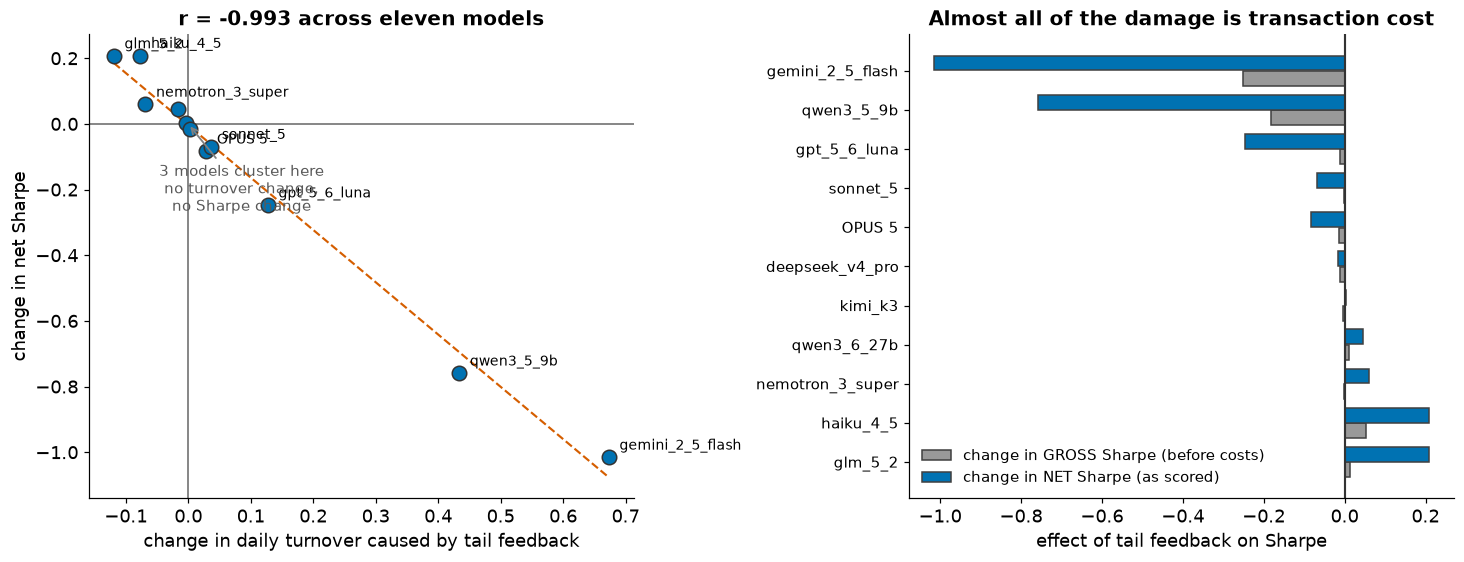

,turn_scalar,turn_distributional,turnover change,gross Sharpe change,net Sharpe change
model,,,,,
glm_5_2,0.4052,0.2858,-0.1194,0.0138,0.2074
haiku_4_5,0.0844,0.0076,-0.0767,0.0528,0.2088
nemotron_3_super,0.3718,0.3030,-0.0687,-0.0008,0.0601
qwen3_6_27b,0.0494,0.0328,-0.0166,0.0117,0.0458
kimi_k3,0.0129,0.0088,-0.0041,-0.0051,0.0028
deepseek_v4_pro,0.0076,0.0103,0.0027,-0.0105,-0.0154
OPUS 5,0.0284,0.0570,0.0287,-0.0128,-0.0828
sonnet_5,0.0109,0.0475,0.0366,-0.0007,-0.0685
gpt_5_6_luna,0.0136,0.1407,0.1271,-0.0122,-0.2467


correlation, turnover change vs NET Sharpe change   : -0.993
correlation, turnover change vs GROSS Sharpe change : -0.975


In [11]:
LEG2 = ["distributional", "scalar"]
Q = D[D.floor & D.arm.isin(LEG2) & (D.line.str.startswith("test_leg_") | (D.line == "test"))].copy()
Q["model"] = Q.line.map(lambda l: "OPUS 5" if l == "test" else l.replace("test_leg_", ""))
g = Q.groupby(["model", "arm"]).agg(net=("sharpe", "mean"), gross=("sharpe_gross", "mean"),
                                    turn=("turnover_mean", "mean")).unstack()
g.columns = ["_".join(c) for c in g.columns]
g["turnover change"] = g["turn_distributional"] - g["turn_scalar"]
g["net Sharpe change"] = g["net_distributional"] - g["net_scalar"]
g["gross Sharpe change"] = g["gross_distributional"] - g["gross_scalar"]
g = g.sort_values("turnover change")

r_net = g[["turnover change", "net Sharpe change"]].corr().iloc[0, 1]
r_gross = g[["turnover change", "gross Sharpe change"]].corr().iloc[0, 1]

fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.0))
ax = axes[0]
ax.scatter(g["turnover change"], g["net Sharpe change"], s=90, color=BLUE, edgecolor="0.2", zorder=3)
# Label only the models that moved. Six of the eleven sit on top of each other at the
# origin, and labelling them made the cluster unreadable while saying nothing.
for m_, r_ in g.iterrows():
    if abs(r_["net Sharpe change"]) > 0.05:
        ax.annotate(m_, (r_["turnover change"], r_["net Sharpe change"]), fontsize=9,
                    xytext=(7, 5), textcoords="offset points")
n_flat = int((g["net Sharpe change"].abs() <= 0.05).sum())
ax.annotate("%d models cluster here" % n_flat + chr(10) + "no turnover change," + chr(10) + "no Sharpe change",
            xy=(0.0, 0.0), xytext=(0.28, 0.62), textcoords="axes fraction", fontsize=9.5,
            color="0.35", ha="center", arrowprops=dict(arrowstyle="->", color="0.5", lw=1.2))
z = np.polyfit(g["turnover change"], g["net Sharpe change"], 1)
xs = np.linspace(g["turnover change"].min(), g["turnover change"].max(), 20)
ax.plot(xs, np.polyval(z, xs), color=RED, lw=1.4, ls="--")
ax.axhline(0, color="0.4", lw=1); ax.axvline(0, color="0.4", lw=1)
ax.set_xlabel("change in daily turnover caused by tail feedback")
ax.set_ylabel("change in net Sharpe")
ax.set_title("r = %+0.3f across eleven models" % r_net, fontsize=13, fontweight="bold")

ax = axes[1]
y = np.arange(len(g))
ax.barh(y - 0.2, g["gross Sharpe change"], height=0.38, color=GREY, edgecolor="0.25",
        label="change in GROSS Sharpe (before costs)")
ax.barh(y + 0.2, g["net Sharpe change"], height=0.38, color=BLUE, edgecolor="0.25",
        label="change in NET Sharpe (as scored)")
ax.axvline(0, color="0.2", lw=1.4)
ax.set_yticks(y); ax.set_yticklabels(g.index, fontsize=9.5)
ax.set_xlabel("effect of tail feedback on Sharpe")
ax.set_title("Almost all of the damage is transaction cost", fontsize=13, fontweight="bold")
ax.legend(fontsize=9.5, loc="lower left")
savefig(fig, FIG / "G9_turnover_unifier.png"); plt.show()

display(g[["turn_scalar", "turn_distributional", "turnover change",
           "gross Sharpe change", "net Sharpe change"]].round(4))
print("correlation, turnover change vs NET Sharpe change   : %+0.3f" % r_net)
print("correlation, turnover change vs GROSS Sharpe change : %+0.3f" % r_gross)

## What it means

**r = −0.993 across eleven models.** Knowing only whether tail feedback made a model trade more or
less nearly predicts whether it gained or lost.

**Gross Sharpe barely moves.** The strategies pick similarly good positions before costs. What
differs is how much they churn.

## The puzzle resolved

| | turnover, scalar | turnover, tail | gross | net |
|---|---|---|---|---|
| `gemini_2_5_flash` | 0.216 | **0.889** | 1.16 → 0.91 | 0.80 → **−0.22** |
| `qwen3_5_9b` | 0.396 | **0.830** | 1.22 → 1.04 | 0.50 → **−0.26** |

**Both fail the same way: tail feedback induced hyperactive rebalancing.** Gross performance held.
Costs destroyed them. **One mechanism, plus one model with a second problem.**

## Why tail feedback would raise turnover

A reward penalising left-tail outcomes can be satisfied cheaply by **cutting losers fast**, which
lowers measured tail risk and costs nothing in a world without fees. **The environment charges fees.
The authored reward may not represent them.**

**Testable prediction:** models whose turnover rose should reference tail statistics without
referencing cost. Models whose turnover fell should reference both. The reward source is archived.
Not yet inspected.

## Why Opus gains

**Opus sits in the middle.** Turnover rose only 0.028 → 0.057, so it paid a small cost for a genuine
tail improvement. **The failures overshot into churn. The Sharpe gainers reduced churn.**

⚠ **Correlation across eleven points, not a manipulation.** Turnover was chosen by the authored
reward, not controlled. The clean test is repricing the grid at different cost levels. Not run.

# 12. Cross-model patterns

Three analyses that use all eleven models.

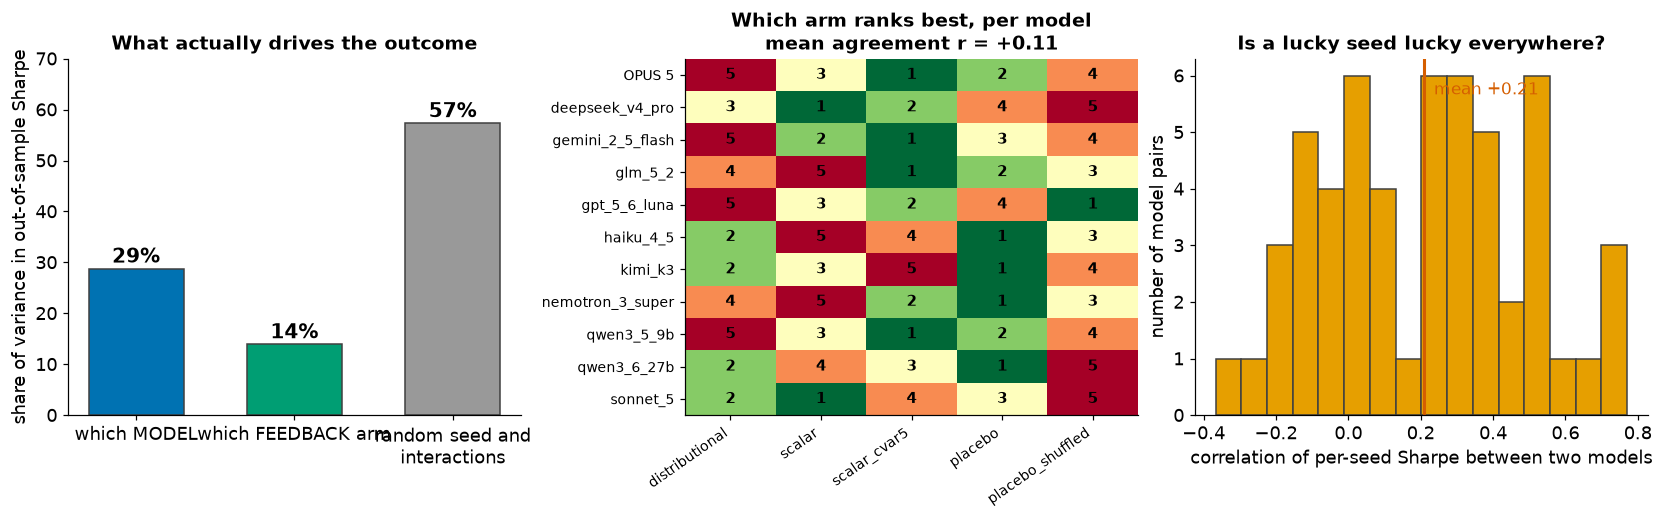

VARIANCE  model 28.8%   arm 13.9%   seed+interaction 57.3%
ARM-RANK AGREEMENT between models: mean r = +0.113
SEED PORTABILITY across models: mean r = +0.209 (range -0.367 to +0.771)


In [12]:
LEG5 = ["distributional", "scalar", "scalar_cvar5", "placebo", "placebo_shuffled"]
A = D[D.floor & D.arm.isin(LEG5) & (D.line.str.startswith("test_leg_") | (D.line == "test"))].copy()
A["model"] = A.line.map(lambda l: "OPUS 5" if l == "test" else l.replace("test_leg_", ""))

tot = A.sharpe.var()
gm, ga = A.groupby("model").sharpe.mean(), A.groupby("arm").sharpe.mean()
v_m, v_a = A.model.map(gm).var(), A.arm.map(ga).var()
resid = (A.sharpe - A.model.map(gm) - A.arm.map(ga) + A.sharpe.mean()).var()

fig, axes = plt.subplots(1, 3, figsize=(15.0, 4.6))
ax = axes[0]
parts = [("which MODEL", 100 * v_m / tot, BLUE), ("which FEEDBACK arm", 100 * v_a / tot, GREEN),
         ("random seed and\ninteractions", 100 * resid / tot, GREY)]
ax.bar([p[0] for p in parts], [p[1] for p in parts], color=[p[2] for p in parts], edgecolor="0.25", width=0.6)
for i, p in enumerate(parts):
    ax.text(i, p[1] + 1.2, "%.0f%%" % p[1], ha="center", fontsize=13, fontweight="bold")
ax.set_ylabel("share of variance in out-of-sample Sharpe")
ax.set_title("What actually drives the outcome", fontsize=12.5, fontweight="bold")
ax.set_ylim(0, 70)

ax = axes[1]
piv = A.groupby(["model", "arm"]).sharpe.mean().unstack()[LEG5]
rk = piv.rank(axis=1, ascending=False)
im = ax.imshow(rk.values, cmap="RdYlGn_r", vmin=1, vmax=5, aspect="auto")
ax.set_xticks(range(5)); ax.set_xticklabels(LEG5, rotation=35, ha="right", fontsize=9)
ax.set_yticks(range(len(rk))); ax.set_yticklabels(rk.index, fontsize=9)
for i in range(rk.shape[0]):
    for j in range(rk.shape[1]):
        ax.text(j, i, int(rk.values[i, j]), ha="center", va="center", fontsize=10, fontweight="bold")
from itertools import combinations
cors = [np.corrcoef(rk.loc[a], rk.loc[b])[0, 1] for a, b in combinations(rk.index, 2)]
ax.set_title("Which arm ranks best, per model\nmean agreement r = %+0.2f" % np.mean(cors),
             fontsize=12.5, fontweight="bold")
ax.grid(False)

ax = axes[2]
sp = A[A.arm == "scalar"].pivot_table(index="seed", columns="model", values="sharpe")
cm = sp.corr().values
iu = cm[np.triu_indices_from(cm, 1)]
ax.hist(iu, bins=16, color=ORANGE, edgecolor="0.25")
ax.axvline(np.nanmean(iu), color=RED, lw=2)
ax.text(np.nanmean(iu), ax.get_ylim()[1] * 0.9, "  mean %+0.2f" % np.nanmean(iu), color=RED, fontsize=11)
ax.set_xlabel("correlation of per-seed Sharpe between two models")
ax.set_ylabel("number of model pairs")
ax.set_title("Is a lucky seed lucky everywhere?", fontsize=12.5, fontweight="bold")
savefig(fig, FIG / "G10_cross_model_patterns.png"); plt.show()

print("VARIANCE  model %.1f%%   arm %.1f%%   seed+interaction %.1f%%"
      % (100 * v_m / tot, 100 * v_a / tot, 100 * resid / tot))
print("ARM-RANK AGREEMENT between models: mean r = %+0.3f" % np.mean(cors))
print("SEED PORTABILITY across models: mean r = %+0.3f (range %+0.3f to %+0.3f)"
      % (np.nanmean(iu), np.nanmin(iu), np.nanmax(iu)))

## 12a. Model choice matters twice as much as feedback design

**Model identity 28.8% of variance. Feedback arm 13.9%. Seed and interactions 57.3%.**

**Practitioner result:** the choice of model is about twice as consequential as the feedback you give
it. **Both are dwarfed by run-to-run randomness**, which is the strongest argument for seed
discipline and against any result based on a handful of runs.

## 12b. The models disagree about which feedback is best

**Mean rank agreement r = +0.11.** `distributional` ranks 1st or 2nd on `haiku_4_5`, `kimi_k3` and
`qwen3_6_27b`, and last on `gemini_2_5_flash`, `gpt_5_6_luna`, `qwen3_5_9b` and Opus.

> **There is no universally best feedback design.**

**This cuts against how the literature reports.** Papers demonstrate a technique on one model and
present it as a property of the technique. **On this evidence that generalises poorly.** Any such
claim should be conditional on the model.

**It also justifies fixing one confirmatory model in advance.** With this much disagreement, choosing
after seeing results would let you report almost anything.

## 12c. Seed luck is mostly model-specific

**Mean between-model correlation of per-seed performance: +0.21** (range −0.37 to +0.77).

A weak shared component exists, probably through shared market data. **Most seed luck is specific to
the model and reward.** So seeds cannot be reused as a variance-reduction device across models. Each
model needs its own depth.

# 13. The two capability ladders

The closest thing to a controlled capability manipulation. **They do not say the same thing.**

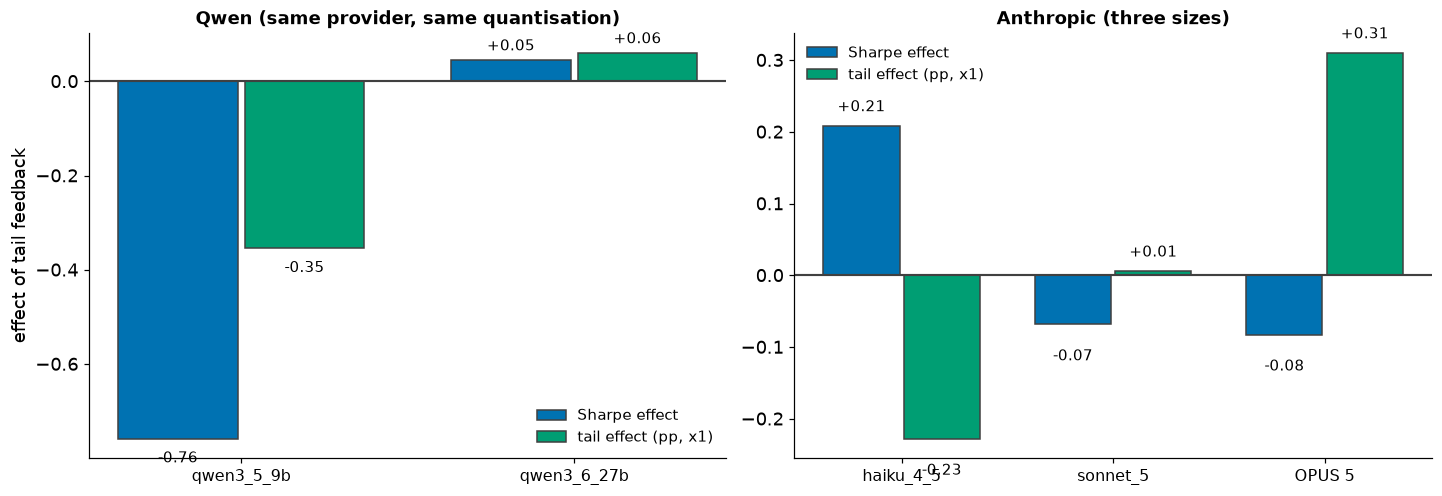

In [13]:
fams = {"Qwen (same provider, same quantisation)": ["qwen3_5_9b", "qwen3_6_27b"],
        "Anthropic (three sizes)": ["haiku_4_5", "sonnet_5", "OPUS 5"]}
fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.4))
for ax, (fam, ms) in zip(axes, fams.items()):
    ms = [m for m in ms if m in piv.index]
    sh = [piv.loc[m, "distributional"] - piv.loc[m, "scalar"] for m in ms]
    cv = []
    for m in ms:
        line = "test" if m == "OPUS 5" else "test_leg_" + m
        cv.append(paired(line, "distributional", "scalar", "oos_cvar_05").mean() * 100)
    x = np.arange(len(ms))
    ax.bar(x - 0.19, sh, width=0.36, color=BLUE, edgecolor="0.25", label="Sharpe effect")
    ax.bar(x + 0.19, cv, width=0.36, color=GREEN, edgecolor="0.25", label="tail effect (pp, x1)")
    ax.axhline(0, color="0.25", lw=1.4)
    ax.set_xticks(x); ax.set_xticklabels(ms, fontsize=10.5)
    ax.set_title(fam, fontsize=12, fontweight="bold")
    ax.legend(fontsize=9.5)
    for i, (a_, b_) in enumerate(zip(sh, cv)):
        ax.text(i - 0.19, a_ + (0.02 if a_ >= 0 else -0.05), "%+.2f" % a_, ha="center", fontsize=10)
        ax.text(i + 0.19, b_ + (0.02 if b_ >= 0 else -0.05), "%+.2f" % b_, ha="center", fontsize=10)
axes[0].set_ylabel("effect of tail feedback")
savefig(fig, FIG / "G11_capability_ladders.png"); plt.show()

## What it means

**The Qwen pair is clean.** Same provider, same quantisation, different size. The 9B is harmed on
both measures. The 27B is harmed on neither.

⚠ **The Anthropic ladder is NOT monotonic on Sharpe.** `haiku_4_5` shows the **largest positive**
effect (+0.21) while the two larger models are slightly negative. **A naive "bigger uses tails
better" story is refuted by its own data.**

**The resolution: the two measures come apart.** On the tail metric, which is what H2-Tail tests,
`haiku_4_5` gets **worse** (−0.23pp) while Opus gets **better** (+0.31pp). Haiku gained Sharpe by
trading less, not by managing its tail.

> **Capability predicts whether a model turns tail information into better tail behaviour. It does
> not predict Sharpe, because Sharpe is dominated by the turnover channel.**

**Raise this yourself.** An examiner who spots the non-monotonic ladder unprompted will assume the
capability story is post-hoc.

# 14. Sub-questions and precision

| | question | evidence | how |
|---|---|---|---|
| **SQ1** | fed signal changes the code? | **Yes.** Selection is tail-blind, so a changed tail has no route except changed code. Turnover, volatility and drawdown all shifted. | by outcome |
| **SQ2** | change reaches the realised tail? | **Yes.** Out-of-sample, surviving both controls. | directly |
| **SQ3** | genuine use, or surface echo? | **Genuine.** Length-matched inert content did not reproduce it, and neither did a single tail scalar. | by controls |

⚠ **All three answered by outcome, not by their registered instruments.** The responsiveness
statistic, mediation decomposition and named-versus-blinded structural test have not been run.
**That is the next analytical step.**

In [14]:
dec = []
for line in ALL11:
    a, b = cell(line, "distributional"), cell(line, "scalar")
    c = a.index.intersection(b.index)
    if len(c) < 5: continue
    x, y = a.loc[c].to_numpy(), b.loc[c].to_numpy(); d = x - y
    dec.append({"model": name(line), "sd distributional": x.std(ddof=1), "sd scalar": y.std(ddof=1),
                "rho": float(np.corrcoef(x, y)[0, 1]), "sd of difference": d.std(ddof=1),
                "seeds for 0.05 margin": int(np.ceil((2 * 1.645 * d.std(ddof=1) / 0.05) ** 2))})
DEC = pd.DataFrame(dec).sort_values("sd of difference")
display(DEC.set_index("model").round(3))
print("Opus: seed sd on the paired difference %.3f, so the Sharpe effect of -0.083 is dz = %.2f"
      % (DEC.set_index("model").loc["OPUS 5", "sd of difference"],
         dz(paired("test", "distributional", "scalar", "sharpe"))))

,sd distributional,sd scalar,rho,sd of difference,seeds for 0.05 margin
model,,,,,
deepseek_v4_pro,0.106,0.101,0.622,0.090,36
haiku_4_5,0.104,0.168,0.676,0.124,67
sonnet_5,0.147,0.130,0.521,0.137,82
kimi_k3,0.100,0.152,0.355,0.149,97
OPUS 5,0.174,0.106,0.431,0.161,112
gpt_5_6_luna,0.172,0.116,-0.006,0.208,188
qwen3_6_27b,0.175,0.184,0.275,0.216,203
qwen3_5_9b,0.209,0.245,0.186,0.291,367
gemini_2_5_flash,0.296,0.200,0.097,0.340,502


Opus: seed sd on the paired difference 0.161, so the Sharpe effect of -0.083 is dz = -0.52


## Precision

**Seed variation is the binding constraint.** Retraining the same reward with a different seed moves
Sharpe by 0.1 to 0.4 units. Most effects here are smaller. **Hence pairing, and hence seven rungs.**

**On Opus, paired noise is 0.161**, so the −0.083 Sharpe effect is about half a standard deviation.
Real but modest, detectable at 30 seeds because pairing removes the shared component.

**Equivalence is harder.** Bounding the Sharpe difference inside the registered 0.05 margin needs
**~112 seeds on Opus**. We have 30. **The difference is real. We cannot yet say it is small.**

⚠ **A pre-launch number does not reproduce.** The pilot recorded paired noise 0.369 and correlation
−0.14. The campaign measures ~0.21 and **+0.23**. **The pilot was pessimistic on a small sample.**
Fewer seeds are needed than believed, though still far more than thirty.

# 15. Why the design carries the result

- **The prediction predates the data.** Three candidate outcomes registered, the "Strict" branch
  predicted, and that is what occurred. The file is hash-sealed.
- **The test is deliberately hostile.** Three legs, no further correction, so the reported p-value is
  the *worst* leg.
- **The stopping rule is exogenous.** 27 August, fixed in advance. Optional stopping is impossible.
- **Selection is tail-blind**, so a tail effect cannot be a selection artefact.
- **Eleven models**, ten report-only, five open-weight and hash-pinned.
- **Common-random-number paired**, with both confirmatory arms in one interleaved array.

> **The result does not depend on trusting the analyst.**

# 16. Limitations

1. **30 seeds, rung 1 of 7.** Direction established, precision not.
2. **Equivalence on the Sharpe leg is undecidable here.** Needs ~112 seeds.
3. **One market, one period, one asset class.** UK and US equities, 2020 to mid-2026.
4. **Cost model fixed and linear.** H1 is sensitive to it. Repricing needs no retraining. Not run.
5. **Mechanism instruments not run.** SQ1 to SQ3 answered by outcome.
6. **H3's explanation is a hypothesis**, and the comparison is confounded by arm.
7. **One model of eleven passes.** The capability account rests on a single within-family pair.
8. **`placebo` is not neutral on every model**, which complicates that control on those lines.
9. **The tail gain is modest** (~0.3pp). Whether it justifies 3.6pp is a preference.
10. **Two archive gaps.** Per-record wall-clock is zero, and the training-return curve was never
    captured.

# 17. Summary for delivery

## In three sentences

> **Feeding a reward designer the realised left tail, rather than a scalar, produces reward code
> whose agent has a measurably less severe tail: worst-day losses of 1.64% against 1.95%, and a
> maximum drawdown of 17.6% against 20.1%. It earns 3.6 percentage points less per year, so the
> risk-adjusted measure falls. The channel works, and the study prices it.**

## Numbers to hold

| | |
|---|---|
| H2-Tail IUT p, worst leg | **< 0.0001, supported** |
| H2-RA | **not supported, as predicted** |
| tail gain vs return cost | **3.9% vs 3.6% a year, roughly one-for-one** |
| human objectives net-profitable | **1 of 11** (11 of 11 gross) |
| models clearing H2-Tail | **1 of 11** |
| turnover change vs Sharpe change | **r = −0.993** |
| variance explained: model / arm / seed | **29% / 14% / 57%** |
| smallest model's code failure rate | **7.9%** on the tail block, **0%** on the scalar |
| seeds to bound Sharpe in the margin | **~112**, we have 30 |

## Anticipated questions

**"Lower Sharpe means it failed."**
It traded return for tail safety, both individually significant. Sharpe imposes one weighting. The
study reports the components separately.

**"Just a longer prompt?"**
A length-matched inert block was run and beaten at p < 0.0001. So was a single tail scalar. The
registered test required beating both.

**"Only one model in eleven."**
Designated in advance, with the reason recorded. The other ten show why: the smallest model's code
fails on 8% of invocations. Using distributional feedback is a capability.

**"Is the tail gain economically meaningful?"**
Roughly one-for-one against return. Attractive for a drawdown-constrained mandate, not for a
return-seeking one. The study supplies the exchange rate, not the preference.

**"Could you have chosen the test afterwards?"**
No. Hypothesis, three-leg rule, metrics and stopping date are in a hash-sealed file predating the
campaign.

## If one exhibit is shown

**Section 5.** The effect and its defence in one chart.